# Result Analysis

In [21]:
import chess
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_style("darkgrid")

ELOS = list(range(900, 2100, 100))

In [22]:
df = pd.read_parquet("../data/recommendation_dataset.parquet")
df.tail()

,fen,next_move,games_count,global_avg_elo,global_winrate,engine_move,delta,fragility_score,variance,group_count_900,...,is_best_1800,is_engine_best_1800,score_1900,recommended_move_1900,is_best_1900,is_engine_best_1900,score_2000,recommended_move_2000,is_best_2000,is_engine_best_2000
265,rnbqkb1r/pp2pp1p/5np1/3p2B1/3P4/2N2N2/PPP2PPP/...,f8g7,104,1678.096154,0.451923,b8c6,0.116353,0.048808,-0.428462,7.0,...,True,<NA>,-0.078964,f8g7,True,<NA>,-0.099973,f8g7,True,<NA>
266,rnbqkb1r/pp3ppp/4pn2/1B1p4/3P4/2N2N2/PPP2PPP/R...,c8d7,110,1599.345455,0.518182,c8d7,0.366785,0.667710,-0.324725,16.0,...,True,True,0.250498,c8d7,True,True,0.210435,c8d7,True,True
267,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,210,1564.290476,0.485714,b8c6,0.295233,0.063857,-0.464949,24.0,...,True,<NA>,-0.023973,f8e7,True,<NA>,-0.048537,f8e7,True,<NA>
268,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,102,1590.254902,0.480392,b8c6,0.259457,0.063857,-0.446934,6.0,...,True,<NA>,-0.030557,f8e7,True,<NA>,-0.054055,f8e7,True,<NA>
269,rnbqkbnr/pp3ppp/4p3/3pP3/3P4/5N2/PP3PPP/RNBQKB...,b8c6,103,1590.407767,0.466019,b8c6,0.116353,-0.760091,-0.446039,11.0,...,True,True,-0.359876,b8c6,True,True,-0.353614,b8c6,True,True


## Prediction accuracy

In [23]:
results = []
grouped = df.groupby("fen").first().reset_index()


def weighted_mean(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return float("nan")
    return (values[mask] * weights[mask]).sum() / weights[mask].sum()


for elo in ELOS:
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"
    group_count_col = f"group_count_{elo}"

    weighted_avg_is_best = weighted_mean(grouped[is_best_col], grouped[group_count_col])
    weighted_avg_is_engine_best = weighted_mean(grouped[is_engine_col], grouped[group_count_col])

    results.append({
        "elo": elo,
        "avg_is_best": weighted_avg_is_best,
        "avg_is_engine_best": weighted_avg_is_engine_best
    })

results = pd.DataFrame(results).set_index("elo")
results

,avg_is_best,avg_is_engine_best
elo,,
900,0.749008,0.705689
1000,0.873899,0.754506
1100,0.883710,0.827689
1200,0.893979,0.841050
1300,0.881010,0.800748
1400,0.874963,0.830780
1500,0.888978,0.846983
1600,0.842683,0.857595
1700,0.857459,0.839040


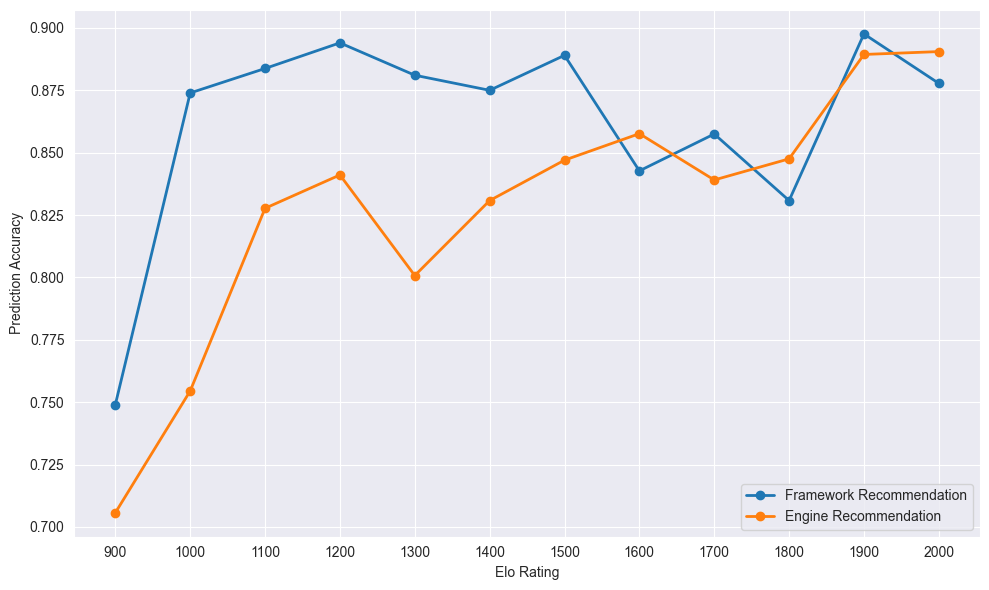

In [24]:
plt.figure(figsize=(10, 6))

for col in results.columns:
    if col == "avg_is_best":
        label = "Framework Recommendation"
    else:
        label = "Engine Recommendation"
    plt.plot(results.index, results[col].values, marker='o', linewidth=2, label=label)

plt.xlabel("Elo Rating")
plt.ylabel("Prediction Accuracy")
plt.xticks(results.index)
plt.legend()
plt.tight_layout()
plt.savefig("../images/prediction_accuracy.svg")
plt.show()

## Move selection decision

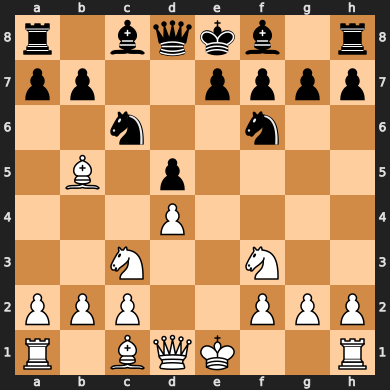

In [25]:
mv_fen = df["fen"].value_counts().idxmax()
chess.Board(mv_fen)

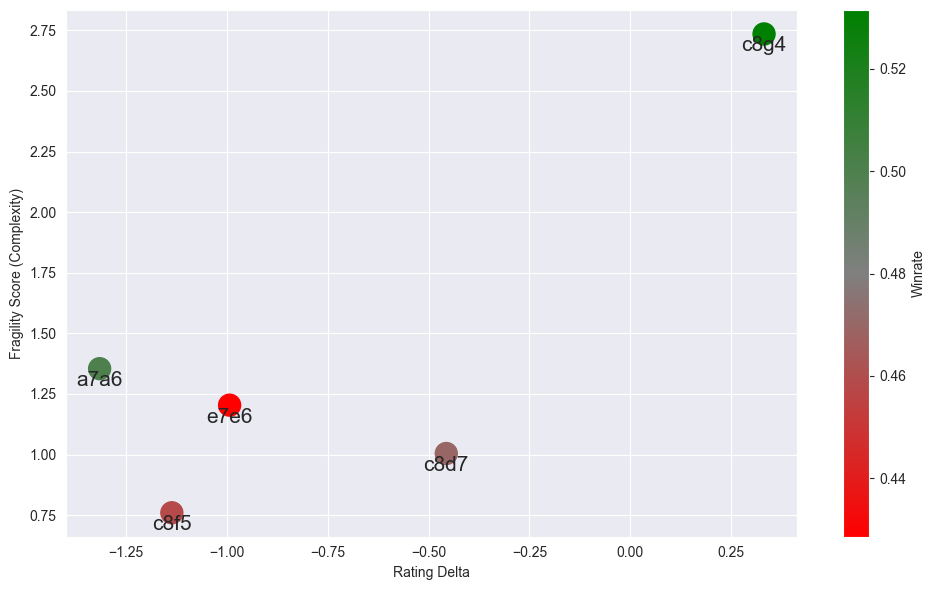

In [26]:
mv_pos = df[df["fen"] == mv_fen]
cmap = mpl.colors.LinearSegmentedColormap.from_list("RG", ["red", "gray", "green"])

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    mv_pos['delta'],
    mv_pos['fragility_score'],
    c=mv_pos['global_winrate'],
    cmap=cmap,
    s=250
)

for _, row in mv_pos.iterrows():
    plt.text(
        row['delta'],
        row['fragility_score'] - 0.01,
        row['next_move'],
        fontsize=15,
        ha='center',
        va='top'
    )

plt.xlabel("Rating Delta")
plt.ylabel("Fragility Score (Complexity)")
plt.colorbar(sc, label='Winrate')
plt.tight_layout()
plt.savefig("../images/selection_decision.svg")
plt.show()

## Sample position

In [27]:
# random_fen = df["fen"].sample(1).iloc[0]
random_fen = "rn1qkbnr/pp3ppp/4p3/3p1b2/3P1B2/2N2N2/PPP2PPP/R2QKB1R b KQkq - 1 6"
filtered = df[df["fen"] == random_fen]
filtered.drop("fen", axis=1).set_index('next_move').T

next_move,b8c6,f8d6,g8f6
games_count,121,147,115
global_avg_elo,1490.347107,1480.217687,1557.06087
global_winrate,0.520661,0.489796,0.530435
engine_move,f8d6,f8d6,f8d6
delta,0.331009,-0.026751,-3.568575
...,...,...,...
is_engine_best_1900,False,False,False
score_2000,-0.104744,0.057834,-1.466954
recommended_move_2000,f8d6,f8d6,f8d6
is_best_2000,True,True,True


In [28]:
print(random_fen)

rn1qkbnr/pp3ppp/4p3/3p1b2/3P1B2/2N2N2/PPP2PPP/R2QKB1R b KQkq - 1 6


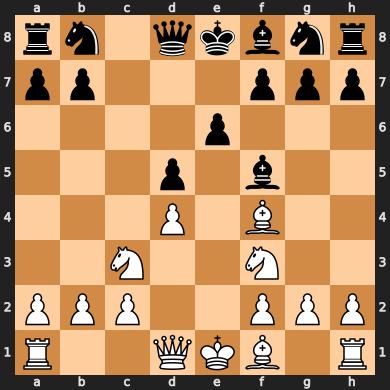

In [29]:
chess.Board(random_fen)

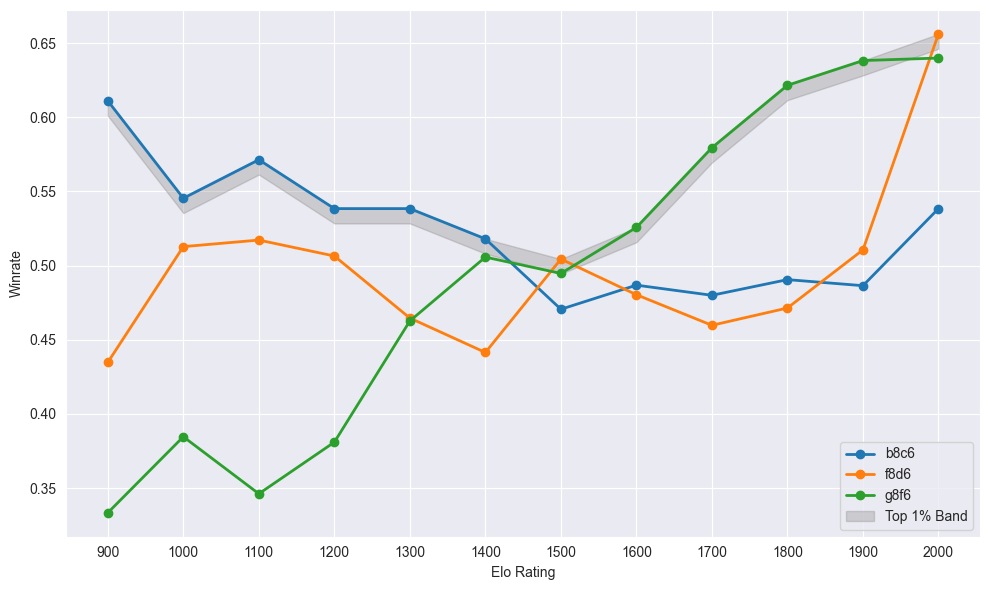

In [30]:
df_sample = filtered.set_index('next_move')
columns_starting_with_winrate = df_sample.columns[df_sample.columns.str.startswith("winrate_")]
filtered_columns_df = df_sample[columns_starting_with_winrate]
filtered_columns_df.columns = filtered_columns_df.columns.str.replace(r"^winrate_", "", regex=True)
winrate_df = filtered_columns_df.T
winrate_df.index = winrate_df.index.astype(int)
top_line = winrate_df.max(axis=1).astype(float).values
bottom_line = (winrate_df.max(axis=1) - 0.01).astype(float).values
elo_index = winrate_df.index.values

plt.figure(figsize=(10, 6))

for col in winrate_df.columns:
    plt.plot(elo_index, winrate_df[col].values, marker='o', linewidth=2, label=col)

plt.fill_between(elo_index, bottom_line, top_line, color='gray', alpha=0.3, label="Top 1% Band")

plt.xlabel("Elo Rating")
plt.ylabel("Winrate")
plt.xticks(winrate_df.index)
plt.legend()
plt.tight_layout()
plt.savefig("../images/winrate_example.svg")
plt.show()

## Evaluate with Logistic Regression and XGBoost

In [31]:
df["f_cross_d"] = df["fragility_score"] * df["delta"]
df["f_cross_v"] = df["fragility_score"] * df["variance"]
df["d_cross_v"] = df["delta"] * df["variance"]

target_columns = [col for col in df.columns if col.startswith("is_best_") or col.startswith("is_engine_best_")]

for y_feature in target_columns:
    print(f"{y_feature}:")
    df_reg = df[pd.notna(df[y_feature])]

    selected_features = ["fragility_score", "delta", "variance", "f_cross_d", "f_cross_v", "d_cross_v"]
    X = df_reg[selected_features]
    y = df_reg[y_feature].astype(bool)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=1, stratify=y
    )

    log_model = LogisticRegression()
    log_model.fit(X_train, y_train)
    y_pred_log = log_model.predict(X_test)
    acc_log = accuracy_score(y_test, y_pred_log)
    print(f"Logistic Regression Accuracy: {acc_log * 100:.1f} %")

    xgb_model = XGBClassifier()
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"XGBoost Accuracy: {acc_xgb * 100:.1f} %")
    print()

is_best_900:
Logistic Regression Accuracy: 58.3 %
XGBoost Accuracy: 58.3 %

is_engine_best_900:
Logistic Regression Accuracy: 63.6 %
XGBoost Accuracy: 36.4 %

is_best_1000:
Logistic Regression Accuracy: 81.8 %
XGBoost Accuracy: 72.7 %

is_engine_best_1000:
Logistic Regression Accuracy: 66.7 %
XGBoost Accuracy: 59.3 %

is_best_1100:
Logistic Regression Accuracy: 74.5 %
XGBoost Accuracy: 80.9 %

is_engine_best_1100:
Logistic Regression Accuracy: 78.9 %
XGBoost Accuracy: 73.7 %

is_best_1200:
Logistic Regression Accuracy: 82.5 %
XGBoost Accuracy: 77.2 %

is_engine_best_1200:
Logistic Regression Accuracy: 80.0 %
XGBoost Accuracy: 73.3 %

is_best_1300:
Logistic Regression Accuracy: 82.0 %
XGBoost Accuracy: 85.2 %

is_engine_best_1300:
Logistic Regression Accuracy: 76.6 %
XGBoost Accuracy: 72.3 %

is_best_1400:
Logistic Regression Accuracy: 80.3 %
XGBoost Accuracy: 78.8 %

is_engine_best_1400:
Logistic Regression Accuracy: 82.0 %
XGBoost Accuracy: 80.0 %

is_best_1500:
Logistic Regression Ac